# Análisis descriptivo espacial de dengue por municipio desde PostgreSQL

Este notebook está ajustado para:

- conectarse a la base `dengue`
- leer `public.valle_mun`
- hacer un análisis descriptivo simple
- construir tabla pivote por año
- generar gráficas básicas
- exportar un mapa HTML interactivo en Folium
- incluir filtros **dentro del mapa HTML** para:
  - **año**
  - **Con Cali / Sin Cali**

## Carpeta de salida del mapa

Los HTML se guardan en:

`G:\Mi unidad\01_UNIVALLE\Doctorado\bd`

## Recomendación de ejecución

Corre las celdas **en orden**, de arriba hacia abajo.  
Si reinicias el kernel, vuelve a ejecutar todo desde el inicio.

In [3]:
# Configuración de conexión
DB_CONFIG = {
    "host": "localhost",
    "port": 5432,
    "database": "dengue",
    "user": "postgres",
    "password": "postgres"
}

SCHEMA = "public"
TABLE = "valle_mun"

# Parámetros base
ANIO = 2024
MUNICIPIO = "CALI"
RUTA_SALIDA = r"G:\Mi unidad\01_UNIVALLE\Doctorado\bd"

In [4]:
import json
from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import folium

from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from branca.element import Element

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [5]:
# Crear conexión
url = URL.create(
    drivername="postgresql+psycopg2",
    username=DB_CONFIG["user"],
    password=DB_CONFIG["password"],
    host=DB_CONFIG["host"],
    port=DB_CONFIG["port"],
    database=DB_CONFIG["database"],
)

engine = create_engine(
    url,
    connect_args={"client_encoding": "utf8"}
)

with engine.connect() as conn:
    print("Conexión exitosa")

Conexión exitosa


## 1. Validación de base de datos y estructura

In [6]:
pd.read_sql("SELECT current_database();", engine)

,current_database
0,dengue


In [7]:
query_cols = f"""
SELECT
    column_name,
    data_type
FROM information_schema.columns
WHERE table_schema = '{SCHEMA}'
  AND table_name = '{TABLE}'
ORDER BY ordinal_position;
"""

df_cols = pd.read_sql(query_cols, engine)
df_cols

,column_name,data_type
0,DPTO_CCDGO,text
1,MPIO_CCDGO,text
2,MPIO_CNMBR,text
3,año,integer
4,población,bigint
5,conteo_dengue,integer
6,incidencia_dengue,numeric
7,geom,USER-DEFINED
8,id,integer


In [8]:
query_preview = f"""
SELECT *
FROM {SCHEMA}.{TABLE}
LIMIT 5;
"""

df_preview = pd.read_sql(query_preview, engine)
df_preview.head()

,DPTO_CCDGO,MPIO_CCDGO,MPIO_CNMBR,año,población,conteo_dengue,incidencia_dengue,geom,id
0,NaN,76400,LA UNIÓN,2026,34699,14,40.35,0106000020110F000001000000010300000001000000BB...,336
1,NaN,76892,YUMBO,2026,115667,39,33.72,0106000020110F00000100000001030000000100000040...,306
2,76,76113,BUGALAGRANDE,2025,26208,10,38.16,0106000020110F000001000000010300000001000000F8...,67
3,76,76109,BUENAVENTURA,2025,324644,170,52.37,0106000020110F000002000000010300000001000000E8...,68
4,76,76122,CAICEDONIA,2025,29646,53,178.78,0106000020110F000001000000010300000001000000EC...,69


## 2. Cargar la base de análisis

In [9]:
query_data = f"""
SELECT
    "MPIO_CCDGO",
    "MPIO_CNMBR",
    "año",
    conteo_dengue,
    geom
FROM {SCHEMA}.{TABLE}
ORDER BY "año", "MPIO_CNMBR";
"""

gdf = gpd.read_postgis(query_data, engine, geom_col="geom")
gdf.head()

,MPIO_CCDGO,MPIO_CNMBR,año,conteo_dengue,geom
0,76020,ALCALÁ,2019,8.0,"MULTIPOLYGON (((-8441648.922 525948.864, -8441..."
1,76036,ANDALUCÍA,2019,21.0,"MULTIPOLYGON (((-8485223.044 469160.288, -8485..."
2,76041,ANSERMANUEVO,2019,10.0,"MULTIPOLYGON (((-8462015.431 544734.501, -8461..."
3,76054,ARGELIA,2019,79.0,"MULTIPOLYGON (((-8476217.717 532139.239, -8476..."
4,76100,BOLÍVAR,2019,16.0,"MULTIPOLYGON (((-8490987.806 500705.117, -8490..."


In [10]:
# Ajustes básicos
gdf["MPIO_CNMBR"] = gdf["MPIO_CNMBR"].astype(str).str.upper().str.strip()
gdf["año"] = pd.to_numeric(gdf["año"], errors="coerce").astype("Int64")
gdf["conteo_dengue"] = pd.to_numeric(gdf["conteo_dengue"], errors="coerce")

print("CRS original:", gdf.crs)
print("Registros:", len(gdf))
print("Municipios únicos:", gdf["MPIO_CNMBR"].nunique())
print("Años:", sorted(gdf["año"].dropna().astype(int).unique().tolist()))

CRS original: EPSG:3857
Registros: 336
Municipios únicos: 42
Años: [2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


## 3. Revisión descriptiva general

In [11]:
resumen = {
    "registros": int(len(gdf)),
    "municipios_unicos": int(gdf["MPIO_CNMBR"].nunique()),
    "anios_unicos": int(gdf["año"].nunique()),
    "anio_min": int(gdf["año"].dropna().min()),
    "anio_max": int(gdf["año"].dropna().max()),
    "casos_totales": float(gdf["conteo_dengue"].sum())
}

pd.DataFrame([resumen])

,registros,municipios_unicos,anios_unicos,anio_min,anio_max,casos_totales
0,336,42,8,2019,2026,163057.0


In [12]:
gdf[["año", "conteo_dengue"]].describe()

,año,conteo_dengue
count,336.0,333.000000
mean,2022.5,489.660661
std,2.294705,2433.740884
min,2019.0,1.000000
25%,2020.75,11.000000
50%,2022.5,40.000000
75%,2024.25,181.000000
max,2026.0,38590.000000


In [13]:
gdf.isna().sum()

MPIO_CCDGO       0
MPIO_CNMBR       0
año              0
conteo_dengue    3
geom             0
dtype: int64

## 4. Casos totales por año

In [14]:
casos_anio = (
    gdf.groupby("año", as_index=False)["conteo_dengue"]
    .sum()
    .sort_values("año")
)

casos_anio

,año,conteo_dengue
0,2019,7446.0
1,2020,20929.0
2,2021,8651.0
3,2022,4362.0
4,2023,23527.0
5,2024,89347.0
6,2025,7799.0
7,2026,996.0


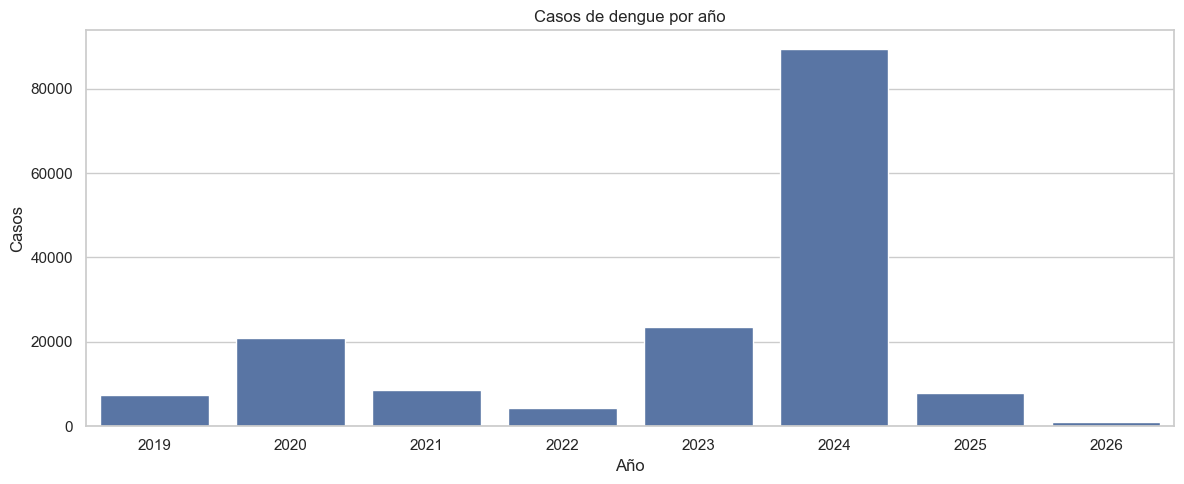

In [15]:
plt.figure(figsize=(12, 5))
sns.barplot(data=casos_anio, x="año", y="conteo_dengue")
plt.title("Casos de dengue por año")
plt.xlabel("Año")
plt.ylabel("Casos")
plt.tight_layout()
plt.show()

## 5. Casos por municipio para un año específico

In [16]:
df_anio = gdf[gdf["año"] == ANIO].copy()
df_anio = df_anio.sort_values("conteo_dengue", ascending=False)

df_anio[["MPIO_CCDGO", "MPIO_CNMBR", "año", "conteo_dengue"]].head(15)

,MPIO_CCDGO,MPIO_CNMBR,año,conteo_dengue
218,76001,CALI,2024,38590.0
236,76520,PALMIRA,2024,5914.0
231,76364,JAMUNDÍ,2024,5578.0
230,76111,GUADALAJARA DE BUGA,2024,5132.0
245,76834,TULUÁ,2024,4258.0
250,76892,YUMBO,2024,3916.0
221,76147,CARTAGO,2024,3452.0
227,76275,FLORIDA,2024,2706.0
225,76248,EL CERRITO,2024,1813.0
222,76233,DAGUA,2024,1690.0


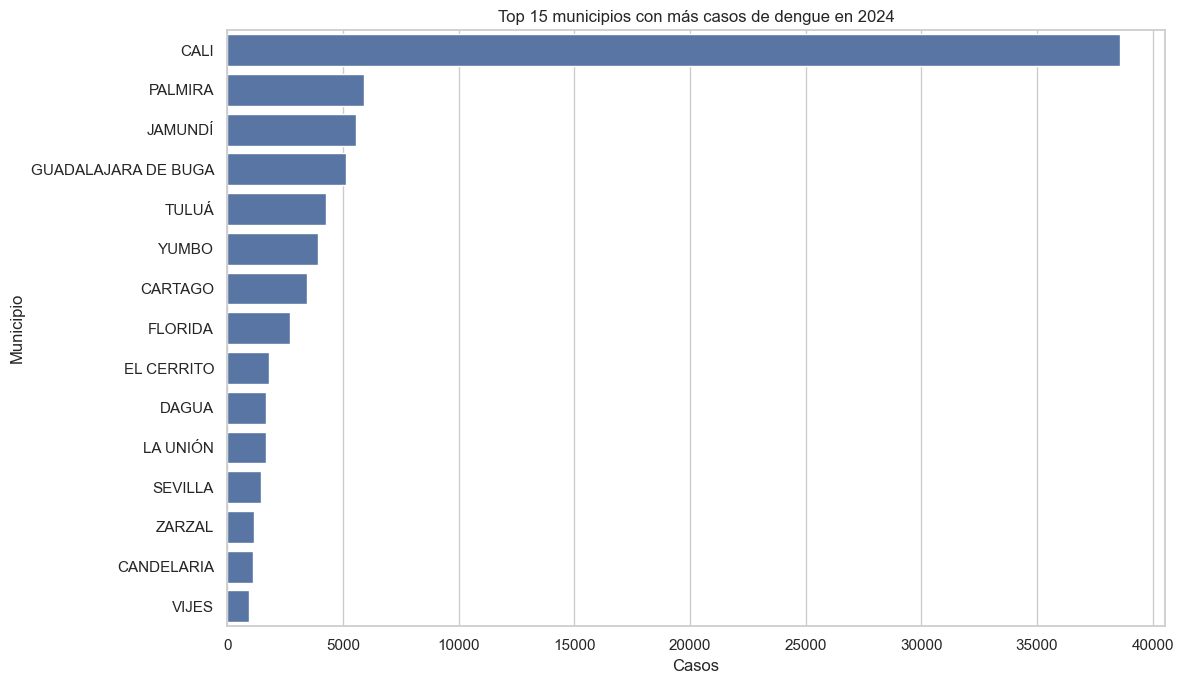

In [17]:
top15 = df_anio[["MPIO_CNMBR", "conteo_dengue"]].head(15)

plt.figure(figsize=(12, 7))
sns.barplot(data=top15, y="MPIO_CNMBR", x="conteo_dengue")
plt.title(f"Top 15 municipios con más casos de dengue en {ANIO}")
plt.xlabel("Casos")
plt.ylabel("Municipio")
plt.tight_layout()
plt.show()

## 6. Tabla pivote por año

In [18]:
pivot_municipios = pd.pivot_table(
    gdf.drop(columns="geom"),
    index=["MPIO_CCDGO", "MPIO_CNMBR"],
    columns="año",
    values="conteo_dengue",
    aggfunc="sum",
    fill_value=0
).reset_index()

pivot_municipios.columns.name = None
pivot_municipios.head()

,MPIO_CCDGO,MPIO_CNMBR,2019,2020,2021,2022,2023,2024,2025,2026
0,76001,CALI,3899.0,10243.0,5853.0,2896.0,13368.0,38590.0,3518.0,489.0
1,76020,ALCALÁ,8.0,24.0,5.0,13.0,8.0,466.0,25.0,1.0
2,76036,ANDALUCÍA,21.0,81.0,38.0,34.0,39.0,388.0,17.0,3.0
3,76041,ANSERMANUEVO,10.0,164.0,38.0,6.0,144.0,882.0,20.0,11.0
4,76054,ARGELIA,79.0,5.0,79.0,79.0,2.0,79.0,1.0,0.0


In [19]:
# Renombrar columnas numéricas a dengue_2019, dengue_2020, etc.
nuevas_cols = []
for col in pivot_municipios.columns:
    if isinstance(col, (int, float, np.integer, np.floating)):
        nuevas_cols.append(f"dengue_{int(col)}")
    else:
        nuevas_cols.append(col)

pivot_municipios.columns = nuevas_cols
pivot_municipios.head()

,MPIO_CCDGO,MPIO_CNMBR,dengue_2019,dengue_2020,dengue_2021,dengue_2022,dengue_2023,dengue_2024,dengue_2025,dengue_2026
0,76001,CALI,3899.0,10243.0,5853.0,2896.0,13368.0,38590.0,3518.0,489.0
1,76020,ALCALÁ,8.0,24.0,5.0,13.0,8.0,466.0,25.0,1.0
2,76036,ANDALUCÍA,21.0,81.0,38.0,34.0,39.0,388.0,17.0,3.0
3,76041,ANSERMANUEVO,10.0,164.0,38.0,6.0,144.0,882.0,20.0,11.0
4,76054,ARGELIA,79.0,5.0,79.0,79.0,2.0,79.0,1.0,0.0


In [20]:
columnas_anio = [col for col in pivot_municipios.columns if str(col).startswith("dengue_")]
anios_disponibles = sorted([int(col.split("_")[1]) for col in columnas_anio])
municipios_disponibles = sorted(pivot_municipios["MPIO_CNMBR"].dropna().astype(str).unique().tolist())

print(columnas_anio)
print(anios_disponibles)

['dengue_2019', 'dengue_2020', 'dengue_2021', 'dengue_2022', 'dengue_2023', 'dengue_2024', 'dengue_2025', 'dengue_2026']
[2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


## 7. Heatmap de municipios vs año

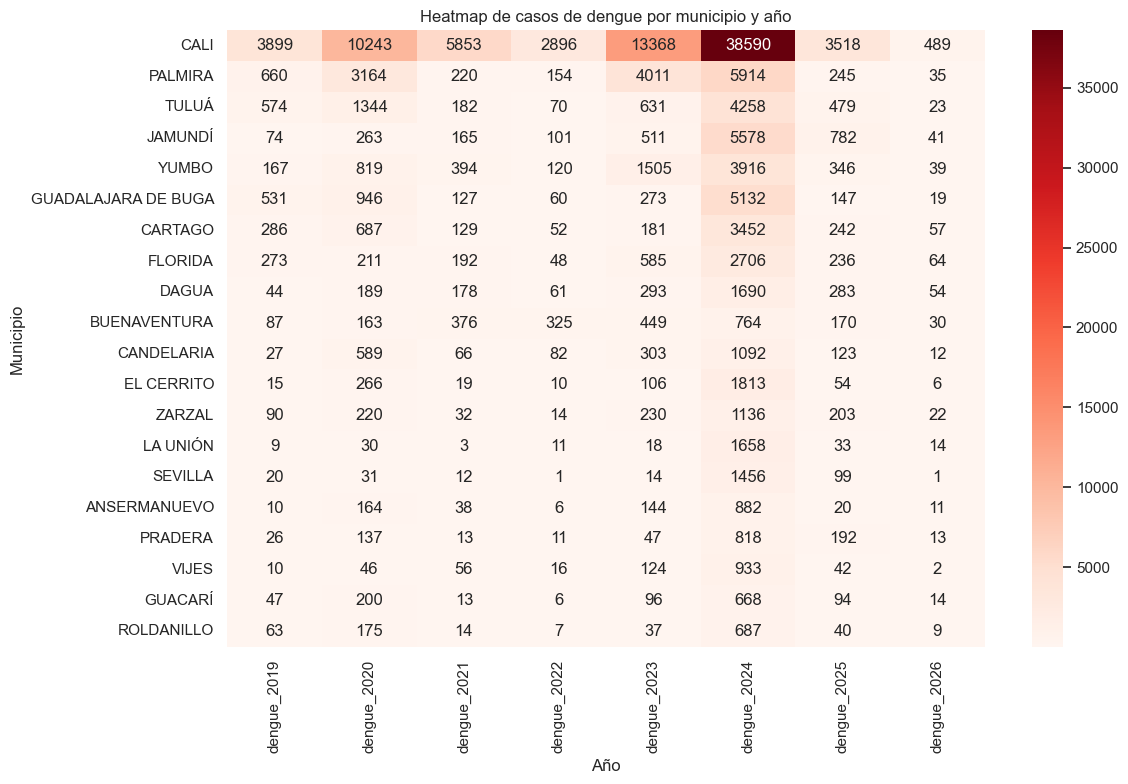

In [21]:
tabla_heat = pivot_municipios.set_index("MPIO_CNMBR")[columnas_anio].copy()
tabla_heat["total"] = tabla_heat.sum(axis=1)
tabla_heat = tabla_heat.sort_values("total", ascending=False).drop(columns="total").head(20)

plt.figure(figsize=(12, 8))
sns.heatmap(tabla_heat, annot=True, fmt=".0f", cmap="Reds")
plt.title("Heatmap de casos de dengue por municipio y año")
plt.xlabel("Año")
plt.ylabel("Municipio")
plt.tight_layout()
plt.show()

In [22]:
# Columnas de años en la tabla pivote
columnas_anio = [
    "dengue_2019", "dengue_2020", "dengue_2021", "dengue_2022",
    "dengue_2023", "dengue_2024", "dengue_2025", "dengue_2026"
]

# Crear tabla de priorización
priorizacion_municipios = pivot_municipios.copy()

priorizacion_municipios["total_2019_2026"] = priorizacion_municipios[columnas_anio].sum(axis=1)

priorizacion_municipios = priorizacion_municipios.sort_values(
    "total_2019_2026",
    ascending=False
).reset_index(drop=True)

priorizacion_municipios.head(20)

,MPIO_CCDGO,MPIO_CNMBR,dengue_2019,dengue_2020,dengue_2021,dengue_2022,dengue_2023,dengue_2024,dengue_2025,dengue_2026,total_2019_2026
0,76001,CALI,3899.0,10243.0,5853.0,2896.0,13368.0,38590.0,3518.0,489.0,78856.0
1,76520,PALMIRA,660.0,3164.0,220.0,154.0,4011.0,5914.0,245.0,35.0,14403.0
2,76834,TULUÁ,574.0,1344.0,182.0,70.0,631.0,4258.0,479.0,23.0,7561.0
3,76364,JAMUNDÍ,74.0,263.0,165.0,101.0,511.0,5578.0,782.0,41.0,7515.0
4,76892,YUMBO,167.0,819.0,394.0,120.0,1505.0,3916.0,346.0,39.0,7306.0
5,76111,GUADALAJARA DE BUGA,531.0,946.0,127.0,60.0,273.0,5132.0,147.0,19.0,7235.0
6,76147,CARTAGO,286.0,687.0,129.0,52.0,181.0,3452.0,242.0,57.0,5086.0
7,76275,FLORIDA,273.0,211.0,192.0,48.0,585.0,2706.0,236.0,64.0,4315.0
8,76233,DAGUA,44.0,189.0,178.0,61.0,293.0,1690.0,283.0,54.0,2792.0
9,76109,BUENAVENTURA,87.0,163.0,376.0,325.0,449.0,764.0,170.0,30.0,2364.0


## 8. Tendencia temporal de un municipio

,año,casos
0,2019,3899.0
1,2020,10243.0
2,2021,5853.0
3,2022,2896.0
4,2023,13368.0
5,2024,38590.0
6,2025,3518.0
7,2026,489.0


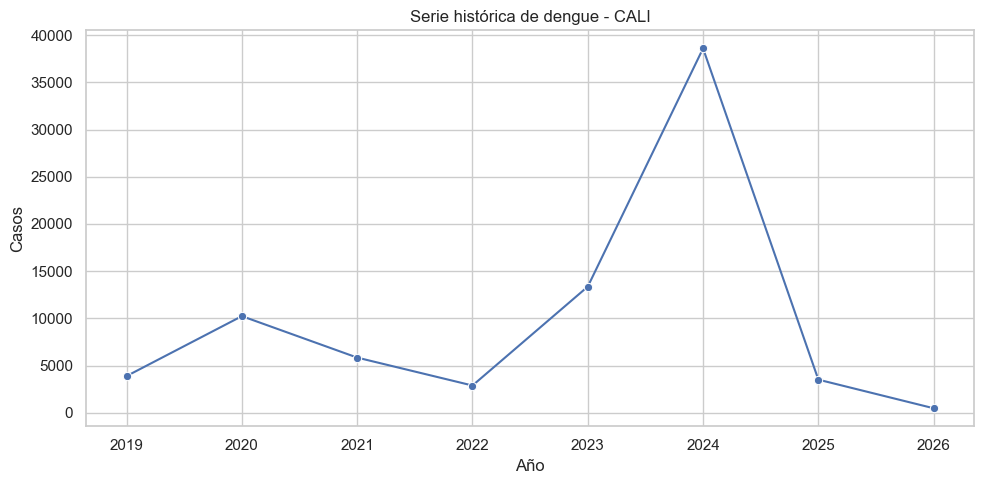

In [23]:
fila = pivot_municipios[pivot_municipios["MPIO_CNMBR"] == MUNICIPIO].copy()

if fila.empty:
    print("No se encontró el municipio.")
else:
    serie = fila[columnas_anio].T.reset_index()
    serie.columns = ["anio_col", "casos"]
    serie["año"] = serie["anio_col"].str.replace("dengue_", "", regex=False).astype(int)
    serie = serie[["año", "casos"]].sort_values("año")
    display(serie)

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=serie, x="año", y="casos", marker="o")
    plt.title(f"Serie histórica de dengue - {MUNICIPIO}")
    plt.xlabel("Año")
    plt.ylabel("Casos")
    plt.tight_layout()
    plt.show()

## 9. Mapa estático por año

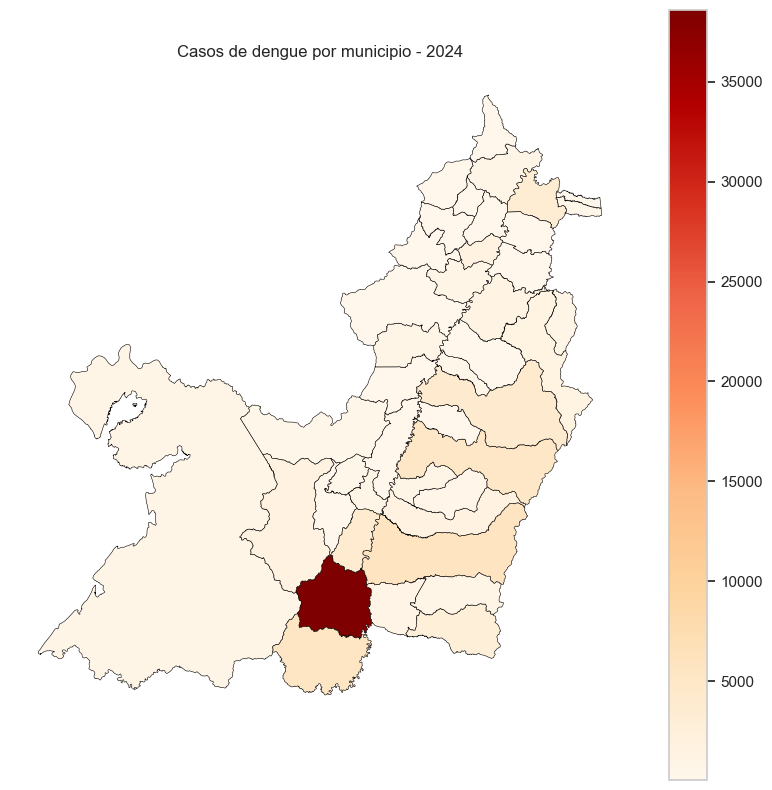

In [24]:
gdf_anio = gdf[gdf["año"] == ANIO].copy()

ax = gdf_anio.plot(
    column="conteo_dengue",
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.4,
    figsize=(10, 10)
)
ax.set_title(f"Casos de dengue por municipio - {ANIO}")
ax.set_axis_off()
plt.show()

## 10. Funciones base para Folium

In [25]:
def filtrar_capa_mapa(gdf, anio, incluir_cali=True):
    gdf_filtrado = gdf[gdf["año"] == anio].copy()
    if not incluir_cali:
        gdf_filtrado = gdf_filtrado[gdf_filtrado["MPIO_CNMBR"] != "CALI"]
    return gdf_filtrado


def preparar_para_folium(gdf_filtrado):
    gdf_map = gdf_filtrado.copy()
    if gdf_map.crs is not None:
        try:
            if gdf_map.crs.to_epsg() != 4326:
                gdf_map = gdf_map.to_crs(4326)
        except Exception:
            pass
    return gdf_map


def corregir_geometrias(gdf_filtrado):
    gdf_fix = gdf_filtrado.copy()
    gdf_fix["geom"] = gdf_fix.geometry.buffer(0)
    gdf_fix = gdf_fix.set_geometry("geom")
    return gdf_fix

## 11. Construir mapa HTML con filtros dentro del mapa

Este bloque genera un HTML con un panel embebido que permite seleccionar:

- **año**
- **Con Cali / Sin Cali**

El archivo resultante se guarda como:

- `mapa_actual.html`
- y además una copia por versión

In [26]:
def preparar_dataset_mapa(gdf, anios):
    datasets = {}

    for anio in anios:
        for incluir_cali in [True, False]:
            clave = f"{anio}_{'con_cali' if incluir_cali else 'sin_cali'}"

            gdf_tmp = filtrar_capa_mapa(gdf, anio=anio, incluir_cali=incluir_cali)
            if gdf_tmp.empty:
                continue

            gdf_tmp = corregir_geometrias(gdf_tmp)
            gdf_tmp = preparar_para_folium(gdf_tmp)

            if not gdf_tmp.empty:
                datasets[clave] = json.loads(gdf_tmp.to_json())

    return datasets

In [27]:
from pathlib import Path
import json
import geopandas as gpd

datasets_mapa = preparar_dataset_mapa(gdf, anios_disponibles)

carpeta_salida = Path(RUTA_SALIDA)
carpeta_salida.mkdir(parents=True, exist_ok=True)

gdf_base = preparar_para_folium(corregir_geometrias(gdf.copy()))
minx, miny, maxx, maxy = gdf_base.total_bounds
centro_lat = (miny + maxy) / 2
centro_lon = (minx + maxx) / 2

datasets_json = json.dumps(datasets_mapa, ensure_ascii=False)
anios_json = json.dumps(anios_disponibles, ensure_ascii=False)

html = f"""
<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="utf-8" />
    <title>Mapa dengue Valle del Cauca</title>
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css"/>
    <style>
        html, body {{
            width: 100%;
            height: 100%;
            margin: 0;
            padding: 0;
            font-family: Arial, sans-serif;
        }}

        #map {{
            width: 100%;
            height: 100vh;
            background: #eef2f5;
        }}

        #control-panel {{
            position: absolute;
            top: 20px;
            left: 20px;
            width: 280px;
            z-index: 9999;
            background: white;
            padding: 14px;
            border-radius: 10px;
            box-shadow: 0 2px 10px rgba(0,0,0,0.25);
            font-size: 14px;
        }}

        #control-panel h4 {{
            margin: 0 0 10px 0;
        }}

        #control-panel select,
        #control-panel button {{
            width: 100%;
            margin-top: 4px;
            margin-bottom: 10px;
            padding: 8px;
            border-radius: 6px;
            border: 1px solid #999;
            box-sizing: border-box;
            font-size: 14px;
        }}

        #btnAplicarMapa {{
            background: #2e7d32;
            color: white;
            border: none;
            cursor: pointer;
        }}

        #btnLimpiarMapa {{
            background: #9e9e9e;
            color: white;
            border: none;
            cursor: pointer;
        }}

        #resumenMapa {{
            margin-top: 10px;
            font-size: 12px;
            color: #222;
            background: #f7f7f7;
            padding: 8px;
            border-radius: 6px;
            line-height: 1.5;
        }}

        #estadoMapa {{
            margin-top: 10px;
            font-size: 12px;
            color: #444;
        }}

        .legend-box {{
            background: white;
            padding: 10px;
            border-radius: 8px;
            box-shadow: 0 2px 8px rgba(0,0,0,0.2);
            font-size: 12px;
            line-height: 1.5;
        }}

        .legend-item {{
            display: flex;
            align-items: center;
            margin-bottom: 4px;
        }}

        .legend-color {{
            width: 14px;
            height: 14px;
            display: inline-block;
            margin-right: 6px;
        }}
    </style>
</head>
<body>
    <div id="map"></div>

    <div id="control-panel">
        <h4>Filtros mapa dengue</h4>

        <label><b>Año</b></label>
        <select id="anioSelect"></select>

        <label><b>Cali</b></label>
        <select id="caliSelect">
            <option value="sin_cali" selected>Sin Cali</option>
            <option value="con_cali">Con Cali</option>
        </select>

        <div style="display:flex; gap:8px;">
            <button id="btnAplicarMapa">Aplicar</button>
            <button id="btnLimpiarMapa">Limpiar</button>
        </div>

        <div id="estadoMapa">Selecciona filtros.</div>
        <div id="resumenMapa">Sin resumen.</div>
    </div>

    <script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
    <script>
        const datasetsDengue = {datasets_json};
        const aniosDisponibles = {anios_json};
        const anioDefault = {ANIO};
        const centroInicial = [{centro_lat}, {centro_lon}];
        const zoomInicial = 7;

        const map = L.map('map', {{
            zoomControl: true,
            preferCanvas: true
        }}).setView(centroInicial, zoomInicial);

        let capaActual = null;
        let leyendaActual = null;

        function formatNumber(x) {{
            return Number(x).toLocaleString('es-CO');
        }}

        function poblarAnios() {{
            const sel = document.getElementById('anioSelect');
            sel.innerHTML = '';
            aniosDisponibles.forEach(a => {{
                const opt = document.createElement('option');
                opt.value = a;
                opt.textContent = a;
                if (a === anioDefault) opt.selected = true;
                sel.appendChild(opt);
            }});
        }}

        function getColor(valor, bins) {{
            if (valor > bins[4]) return '#bd0026';
            if (valor > bins[3]) return '#f03b20';
            if (valor > bins[2]) return '#fd8d3c';
            if (valor > bins[1]) return '#fecc5c';
            return '#ffffb2';
        }}

        function calcularBins(valores) {{
            const vals = valores
                .filter(v => v !== null && !isNaN(v))
                .map(v => Number(v))
                .sort((a, b) => a - b);

            if (vals.length === 0) return [0, 1, 2, 3, 4];

            const quant = frac => vals[Math.floor((vals.length - 1) * frac)];
            return [quant(0.2), quant(0.4), quant(0.6), quant(0.8), quant(0.95)];
        }}

        function crearLeyenda(bins, anio) {{
            if (leyendaActual) {{
                map.removeControl(leyendaActual);
            }}

            leyendaActual = L.control({{ position: 'topright' }});

            leyendaActual.onAdd = function() {{
                const div = L.DomUtil.create('div', 'legend-box');
                const colores = ['#ffffb2','#fecc5c','#fd8d3c','#f03b20','#bd0026'];

                div.innerHTML = '<b>Casos de dengue ' + anio + '</b><br>';

                let desde = 0;
                for (let i = 0; i < bins.length; i++) {{
                    const hasta = Math.round(bins[i]);
                    div.innerHTML += `
                        <div class="legend-item">
                            <span class="legend-color" style="background:${{colores[i]}}"></span>
                            <span>${{formatNumber(desde)}} - ${{formatNumber(hasta)}}</span>
                        </div>
                    `;
                    desde = hasta + 1;
                }}

                return div;
            }};

            leyendaActual.addTo(map);
        }}

        function limpiarMapa() {{
            document.getElementById('anioSelect').value = String(anioDefault);
            document.getElementById('caliSelect').value = 'sin_cali';
            actualizarMapaDengue();
        }}

        function actualizarMapaDengue() {{
            const anio = document.getElementById('anioSelect').value;
            const cali = document.getElementById('caliSelect').value;
            const clave = anio + '_' + cali;
            const data = datasetsDengue[clave];

            if (!data || !data.features || data.features.length === 0) {{
                document.getElementById('estadoMapa').innerHTML = 'No hay datos para esa combinación.';
                document.getElementById('resumenMapa').innerHTML = 'Sin resumen.';
                return;
            }}

            if (capaActual) {{
                map.removeLayer(capaActual);
            }}

            const valores = data.features.map(f => f.properties["conteo_dengue"]);
            const bins = calcularBins(valores);
            const totalCasos = valores.reduce((acc, v) => acc + Number(v || 0), 0);
            const totalMunicipios = data.features.length;

            capaActual = L.geoJSON(data, {{
                style: function(feature) {{
                    const props = feature.properties || {{}};
                    return {{
                        fillColor: getColor(props["conteo_dengue"], bins),
                        weight: 1,
                        opacity: 1,
                        color: 'black',
                        fillOpacity: 0.75
                    }};
                }},
                onEachFeature: function(feature, layer) {{
                    const props = feature.properties || {{}};

                    layer.bindTooltip(
                        '<b>Municipio:</b> ' + (props["MPIO_CNMBR"] || '') + '<br>' +
                        '<b>Año:</b> ' + (props["año"] || '') + '<br>' +
                        '<b>Casos:</b> ' + formatNumber(props["conteo_dengue"] || 0)
                    );

                    layer.bindPopup(
                        '<b>Municipio:</b> ' + (props["MPIO_CNMBR"] || '') + '<br>' +
                        '<b>Código:</b> ' + (props["MPIO_CCDGO"] || '') + '<br>' +
                        '<b>Año:</b> ' + (props["año"] || '') + '<br>' +
                        '<b>Casos:</b> ' + formatNumber(props["conteo_dengue"] || 0)
                    );

                    layer.on({{
                        mouseover: function(e) {{
                            e.target.setStyle({{
                                weight: 3,
                                color: '#333',
                                fillOpacity: 0.9
                            }});
                        }},
                        mouseout: function(e) {{
                            if (capaActual) {{
                                capaActual.resetStyle(e.target);
                            }}
                        }}
                    }});
                }}
            }}).addTo(map);

            try {{
                map.fitBounds(capaActual.getBounds());
            }} catch (err) {{
                console.log(err);
                map.setView(centroInicial, zoomInicial);
            }}

            crearLeyenda(bins, anio);

            document.getElementById('estadoMapa').innerHTML =
                'Mostrando año <b>' + anio + '</b> y filtro <b>' + cali.replace('_', ' ') + '</b>.';

            document.getElementById('resumenMapa').innerHTML =
                '<b>Municipios visibles:</b> ' + formatNumber(totalMunicipios) + '<br>' +
                '<b>Total casos:</b> ' + formatNumber(totalCasos);
        }}

        document.getElementById('btnAplicarMapa').addEventListener('click', actualizarMapaDengue);
        document.getElementById('btnLimpiarMapa').addEventListener('click', limpiarMapa);
        document.getElementById('anioSelect').addEventListener('change', actualizarMapaDengue);
        document.getElementById('caliSelect').addEventListener('change', actualizarMapaDengue);

        poblarAnios();
        actualizarMapaDengue();
    </script>
</body>
</html>
"""

ruta_html = carpeta_salida / "mapa_actual.html"
with open(ruta_html, "w", encoding="utf-8") as f:
    f.write(html)

print("Mapa actualizado en:")
print(ruta_html)

Mapa actualizado en:
G:\Mi unidad\01_UNIVALLE\Doctorado\bd\mapa_actual.html


In [28]:
print(sorted(datasets_mapa.keys())[:10])
for k in sorted(datasets_mapa.keys())[:5]:
    print(k, len(datasets_mapa[k]["features"]))

['2019_con_cali', '2019_sin_cali', '2020_con_cali', '2020_sin_cali', '2021_con_cali', '2021_sin_cali', '2022_con_cali', '2022_sin_cali', '2023_con_cali', '2023_sin_cali']
2019_con_cali 42
2019_sin_cali 41
2020_con_cali 42
2020_sin_cali 41
2021_con_cali 42


## 12. Exportar la tabla pivote si la necesitas

In [29]:
# Exportar la tabla pivote
# pivot_municipios.to_csv(Path(RUTA_SALIDA) / "valle_mun_pivot.csv", index=False)

# Exportar capa filtrada por año como GeoPackage
# gdf_anio.to_file(Path(RUTA_SALIDA) / f"valle_mun_{ANIO}.gpkg", driver="GPKG")

## Nota final

Si abres `mapa_actual.html`, los filtros quedan **dentro del mapa** y funcionan sin depender del notebook.